# Tarea Sesion 26 - Broadcasting en NumPy

**Materia:** Programacion para Ciencia de Datos  
**Semana 9**

En esta tarea se practica el concepto de broadcasting en NumPy. Broadcasting es cuando NumPy hace operaciones entre arrays de diferente forma de manera automatica, sin necesidad de usar bucles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Ejercicio 1: Normalizar datos de sensores

Se tienen datos de 4 sensores con 6 mediciones cada uno. Cada sensor tiene diferente escala, por eso se necesita normalizar para poder compararlos.

La formula de normalizacion min-max es:

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Con broadcasting, se puede hacer esto sin usar bucles for.

In [2]:
# Datos de sensores (6 mediciones x 4 sensores)
datos_sensores = np.array([
    [20.5, 1013.2, 65.3, 22.1],
    [21.3, 1015.8, 68.7, 23.5],
    [19.8, 1012.5, 63.2, 21.8],
    [22.1, 1016.3, 70.1, 24.2],
    [20.2, 1014.1, 66.5, 22.8],
    [21.7, 1015.5, 69.3, 23.9]
])

print("Datos originales:")
print(datos_sensores)
print(f"Forma: {datos_sensores.shape}")

Datos originales:
[[  20.5 1013.2   65.3   22.1]
 [  21.3 1015.8   68.7   23.5]
 [  19.8 1012.5   63.2   21.8]
 [  22.1 1016.3   70.1   24.2]
 [  20.2 1014.1   66.5   22.8]
 [  21.7 1015.5   69.3   23.9]]
Forma: (6, 4)


In [3]:
# Calcular minimos y maximos por columna (axis=0)
mins = datos_sensores.min(axis=0)
maxs = datos_sensores.max(axis=0)

print("Minimos por sensor:", mins)
print("Maximos por sensor:", maxs)

# Aplicar normalizacion
# Aqui es donde pasa el broadcasting: mins y maxs tienen forma (4,)
# pero datos_sensores tiene forma (6, 4)
# NumPy automaticamente replica mins y maxs para cada fila
datos_norm = (datos_sensores - mins) / (maxs - mins)

print("\nDatos normalizados:")
print(datos_norm)

Minimos por sensor: [  19.8 1012.5   63.2   21.8]
Maximos por sensor: [  22.1 1016.3   70.1   24.2]

Datos normalizados:
[[0.30434783 0.18421053 0.30434783 0.125     ]
 [0.65217391 0.86842105 0.79710145 0.70833333]
 [0.         0.         0.         0.        ]
 [1.         1.         1.         1.        ]
 [0.17391304 0.42105263 0.47826087 0.41666667]
 [0.82608696 0.78947368 0.88405797 0.875     ]]


In [4]:
# Verificar que funciono correctamente
print("Minimos despues de normalizar (deberian ser ~0):")
print(datos_norm.min(axis=0))

print("\nMaximos despues de normalizar (deberian ser ~1):")
print(datos_norm.max(axis=0))

Minimos despues de normalizar (deberian ser ~0):
[0. 0. 0. 0.]

Maximos despues de normalizar (deberian ser ~1):
[1. 1. 1. 1.]


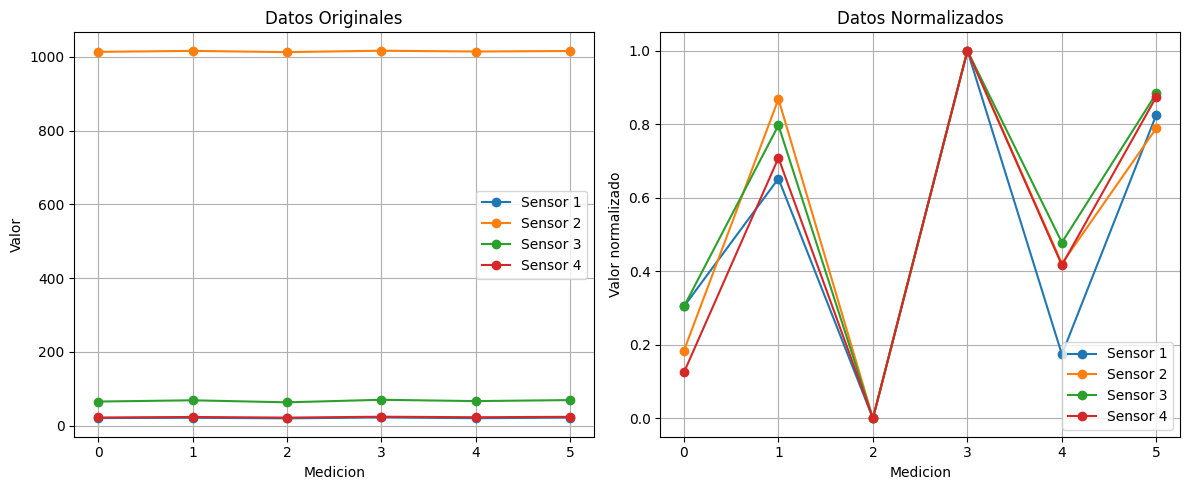

In [5]:
# Comparar datos originales vs normalizados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(datos_sensores, marker='o')
plt.title('Datos Originales')
plt.xlabel('Medicion')
plt.ylabel('Valor')
plt.legend(['Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4'])
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(datos_norm, marker='o')
plt.title('Datos Normalizados')
plt.xlabel('Medicion')
plt.ylabel('Valor normalizado')
plt.legend(['Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4'])
plt.grid(True)

plt.tight_layout()
plt.show()

**Conclusiones del Ejercicio 1:**

- Broadcasting hace que NumPy replique automaticamente un vector cuando lo operas con una matriz, no se necesitan bucles for
- Ahora todos los sensores estan en la misma escala [0, 1], lo que hace mas facil compararlos
- Esto es importante en machine learning para que ninguna variable tenga mas peso solo porque tiene valores mas grandes
- La operacion fue muy rapida comparada con hacer un bucle

## Ejercicio 2: Aplicar pesos a calificaciones

Se tienen calificaciones de 5 estudiantes en 4 examenes. Cada examen tiene diferente peso (importancia). Se necesita calcular el promedio ponderado de cada estudiante usando broadcasting.

In [6]:
# Calificaciones (5 estudiantes x 4 examenes)
calificaciones = np.array([
    [85, 78, 92, 88],  # Estudiante 1
    [76, 82, 85, 80],  # Estudiante 2
    [90, 88, 95, 92],  # Estudiante 3
    [70, 75, 78, 72],  # Estudiante 4
    [82, 85, 88, 86]   # Estudiante 5
])

# Pesos de cada examen (deben sumar 1.0)
pesos = np.array([0.15, 0.25, 0.35, 0.25])

print("Calificaciones:")
print(calificaciones)
print(f"\nPesos: {pesos}")
print(f"Suma de pesos: {pesos.sum()}")

Calificaciones:
[[85 78 92 88]
 [76 82 85 80]
 [90 88 95 92]
 [70 75 78 72]
 [82 85 88 86]]

Pesos: [0.15 0.25 0.35 0.25]
Suma de pesos: 1.0


In [7]:
# Aplicar pesos usando broadcasting
# pesos tiene forma (4,) y calificaciones tiene forma (5, 4)
# Al multiplicar, NumPy aplica los pesos a cada fila (estudiante)
calif_ponderadas = calificaciones * pesos

print("Calificaciones ponderadas:")
print(calif_ponderadas)

# Sumar por filas para obtener el promedio final de cada estudiante
promedios = calif_ponderadas.sum(axis=1)

print("\nPromedios finales:")
for i, prom in enumerate(promedios):
    print(f"Estudiante {i+1}: {prom:.2f}")

Calificaciones ponderadas:
[[12.75 19.5  32.2  22.  ]
 [11.4  20.5  29.75 20.  ]
 [13.5  22.   33.25 23.  ]
 [10.5  18.75 27.3  18.  ]
 [12.3  21.25 30.8  21.5 ]]

Promedios finales:
Estudiante 1: 86.45
Estudiante 2: 81.65
Estudiante 3: 91.75
Estudiante 4: 74.55
Estudiante 5: 85.85


In [8]:
# Comparar con promedio simple (sin pesos)
promedio_simple = calificaciones.mean(axis=1)

print("Comparacion:")
print("Estudiante | Prom. Simple | Prom. Ponderado | Diferencia")
print("-" * 60)
for i in range(5):
    dif = promedios[i] - promedio_simple[i]
    print(f"Estudiante {i+1} |    {promedio_simple[i]:.2f}      |      {promedios[i]:.2f}       |   {dif:+.2f}")

Comparacion:
Estudiante | Prom. Simple | Prom. Ponderado | Diferencia
------------------------------------------------------------
Estudiante 1 |    85.75      |      86.45       |   +0.70
Estudiante 2 |    80.75      |      81.65       |   +0.90
Estudiante 3 |    91.25      |      91.75       |   +0.50
Estudiante 4 |    73.75      |      74.55       |   +0.80
Estudiante 5 |    85.25      |      85.85       |   +0.60


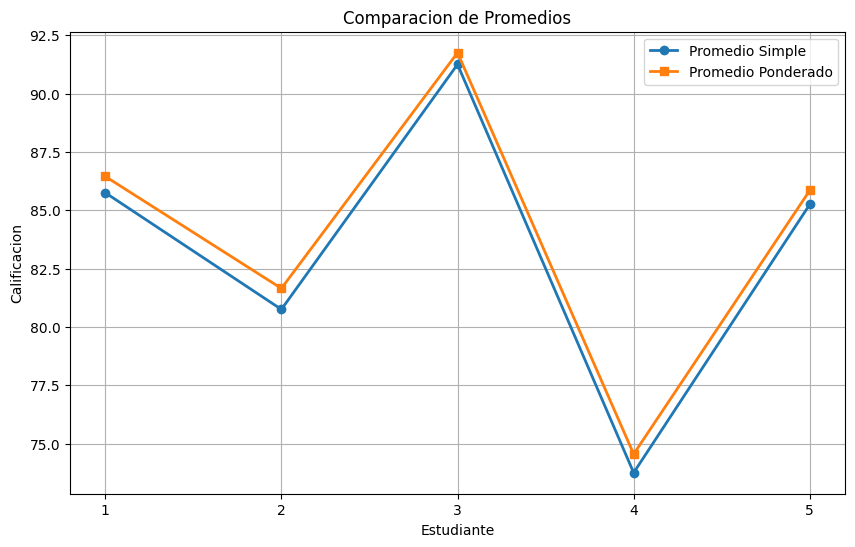

In [9]:
# Grafica de comparacion
x = np.arange(1, 6)

plt.figure(figsize=(10, 6))
plt.plot(x, promedio_simple, marker='o', label='Promedio Simple', linewidth=2)
plt.plot(x, promedios, marker='s', label='Promedio Ponderado', linewidth=2)
plt.xlabel('Estudiante')
plt.ylabel('Calificacion')
plt.title('Comparacion de Promedios')
plt.legend()
plt.grid(True)
plt.xticks(x)
plt.show()

**Conclusiones del Ejercicio 2:**

- Con broadcasting se puede multiplicar una matriz por un vector y el vector se aplica a cada fila automaticamente
- Los promedios ponderados dan mas importancia a los examenes con mayor peso
- Se nota que algunos estudiantes subieron y otros bajaron dependiendo de en que examenes les fue mejor
- Esto es mas justo que el promedio simple cuando unos examenes son mas importantes que otros

## Ejercicio 3: Evaluar funciones en una malla 2D

Se va a crear una malla de puntos (x, y) y evaluar funciones matematicas en ella. Esto se usa mucho para graficar funciones de dos variables.

In [10]:
# Crear vectores x e y con 50 puntos cada uno
x = np.linspace(-3, 3, 50)
y = np.linspace(-3, 3, 50)

print(f"x tiene {len(x)} puntos")
print(f"y tiene {len(y)} puntos")

# Para usar broadcasting, cambio la forma de los vectores
# x se hace columna: (50, 1)
# y se hace fila: (1, 50)
x = x[:, np.newaxis]
y = y[np.newaxis, :]

print(f"\nDespues del cambio:")
print(f"Forma de x: {x.shape}")
print(f"Forma de y: {y.shape}")

x tiene 50 puntos
y tiene 50 puntos

Despues del cambio:
Forma de x: (50, 1)
Forma de y: (1, 50)


In [11]:
# Evaluar la funcion f(x, y) = sin(x) * cos(y)
# Con broadcasting, esto funciona automaticamente
# x tiene forma (50, 1) e y tiene forma (1, 50)
# El resultado tendra forma (50, 50)
Z = np.sin(x) * np.cos(y)

print(f"Forma del resultado: {Z.shape}")
print(f"Valores van de {Z.min():.2f} a {Z.max():.2f}")

Forma del resultado: (50, 50)
Valores van de -1.00 a 1.00


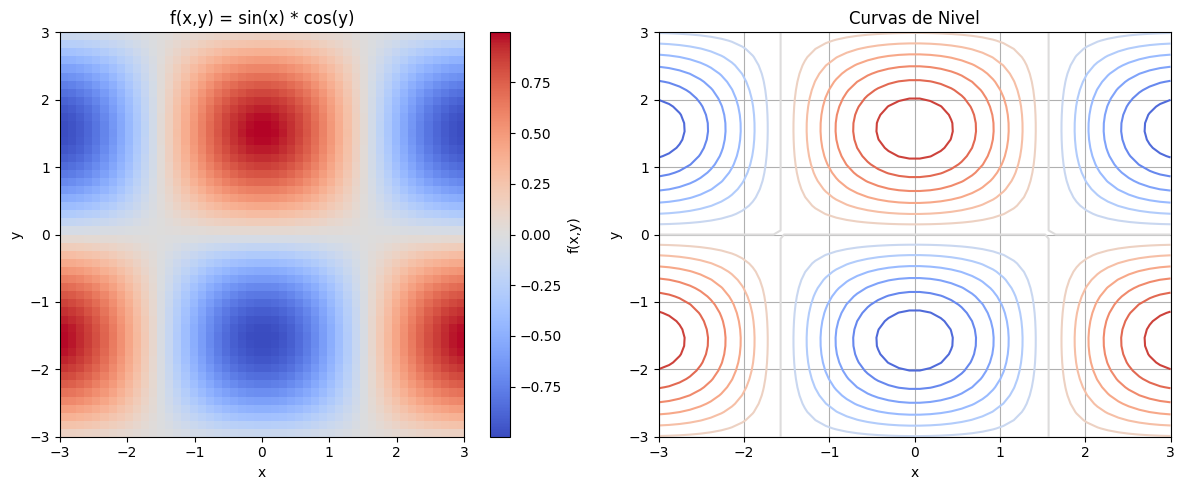

In [12]:
# Graficar la funcion
plt.figure(figsize=(12, 5))

# Mapa de calor
plt.subplot(1, 2, 1)
plt.imshow(Z, extent=[-3, 3, -3, 3], origin='lower', cmap='coolwarm')
plt.colorbar(label='f(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('f(x,y) = sin(x) * cos(y)')

# Curvas de nivel
plt.subplot(1, 2, 2)
# Necesito volver x e y a 2D para contour
x_1d = x.flatten()
y_1d = y.flatten()
X, Y = np.meshgrid(x_1d, y_1d)
plt.contour(X, Y, Z, levels=15, cmap='coolwarm')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curvas de Nivel')
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Otra funcion: gaussiana 2D
# f(x, y) = exp(-(x^2 + y^2)/2)
Z_gauss = np.exp(-(x**2 + y**2) / 2)

print(f"Valor maximo (en el centro): {Z_gauss.max():.4f}")
print(f"Valor en las esquinas: {Z_gauss[0, 0]:.6f}")

Valor maximo (en el centro): 0.9963
Valor en las esquinas: 0.000123


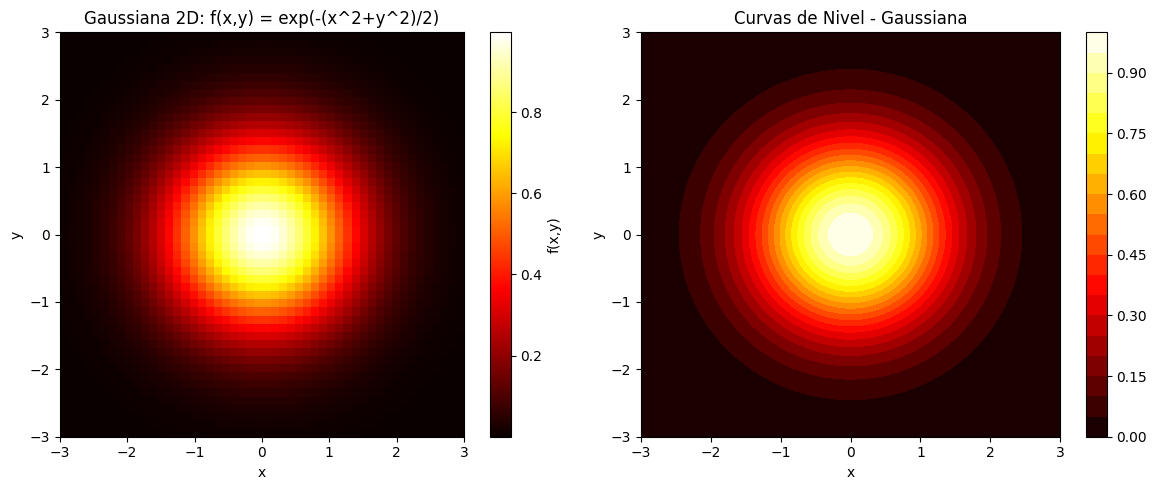

In [14]:
# Graficar la gaussiana
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(Z_gauss, extent=[-3, 3, -3, 3], origin='lower', cmap='hot')
plt.colorbar(label='f(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gaussiana 2D: f(x,y) = exp(-(x^2+y^2)/2)')

plt.subplot(1, 2, 2)
plt.contourf(X, Y, Z_gauss, levels=20, cmap='hot')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curvas de Nivel - Gaussiana')

plt.tight_layout()
plt.show()

**Conclusiones del Ejercicio 3:**

- Se pudo crear una malla completa de 50x50 = 2500 puntos usando solo dos vectores y broadcasting
- No se necesitaron bucles para evaluar la funcion en todos los puntos
- Las graficas muestran bien el comportamiento de las funciones
- La primera funcion oscila entre -1 y 1, la gaussiana tiene un pico en el centro y baja hacia los lados
- Este metodo es muy util para visualizar funciones de dos variables

## Resumen de la tarea

En esta tarea se practico el concepto de broadcasting en NumPy con tres ejercicios:

1. **Normalizacion de datos:** Se normalizo una matriz de datos de sensores usando broadcasting para aplicar la formula a todas las columnas sin bucles

2. **Promedios ponderados:** Se aplicaron pesos diferentes a las calificaciones de varios estudiantes usando broadcasting para multiplicar la matriz por un vector

3. **Evaluacion de funciones 2D:** Se creo una malla de puntos y se evaluaron funciones matematicas usando broadcasting para generar matrices completas

**Lo que aprendi:**

- Broadcasting es muy util para evitar bucles y hacer el codigo mas rapido
- NumPy replica automaticamente los arrays cuando tienen formas compatibles
- Se puede usar para normalizar datos, calcular promedios ponderados y evaluar funciones
- Es importante entender las formas (shapes) de los arrays para que broadcasting funcione correctamente
- Cuando tienes dudas sobre las formas, siempre es bueno imprimir el shape para verificar